# Etape 1 : Chargement

### Combien de clients ? Combien de transactions ? Sur quelle période ?

In [4]:
import pandas as pd
import numpy as np

# Chargement
df_transaction = pd.read_csv("../../data/transactions.csv")
df_client = pd.read_csv("../../data/customers.csv")

print(len(df_transaction))
print(len(df_client["customer_id"].unique()))
print(df_transaction["invoice_date"].min())
print(df_transaction["invoice_date"].max())

# Il y a 1837137 transaction, 50000 clients uniques
# Les dates de transaction s'étalent du 2007-07-06 au 2011-12-09 

1837137
50000
2007-07-06 12:20:00
2011-12-09 12:50:00


### Y a-t-il des doublons ?

In [3]:
df_transaction_without_duplicates = df_transaction.drop_duplicates()
print(len(df_transaction) - len(df_transaction_without_duplicates))

#Il y a 34522 doublons dans df_transaction

df_customer_without_duplicates = df_client.drop_duplicates()
print(len(df_client) - len(df_customer_without_duplicates))
#Il y a 0 doublons dans df_client


34522
0


In [4]:
print(df_transaction.head())

  invoice_id  customer_id product_code                      product_name  \
0     513574          NaN        22382        LUNCH BAG SPACEBOY DESIGN    
1     609421          NaN        21028          PURPLE GEMSTONE BRACELET   
2     515609          NaN       47591B          SCOTTIES CHILDRENS APRON   
3     501320      15123.0        22334  DINOSAUR PARTY BAG + STICKER SET   
4     521822      12714.0        21933   PINK VINTAGE PAISLEY PICNIC BAG   

   quantity  unit_price         invoice_date         country  
0       2.0        4.21  2010-06-25 15:13:00  United Kingdom  
1       2.0        8.95  2011-10-16 12:20:00  United Kingdom  
2       1.0        1.66  2010-07-13 15:44:00  United Kingdom  
3       8.0        1.65  2010-03-16 09:49:00  United Kingdom  
4       5.0        2.95  2010-09-09 10:37:00          France  


### Quelles colonnes contiennent des valeurs manquantes, et dans quelle proportion ?

In [5]:
#colonnes valeurs manquantes et proportion
missing_values = df_transaction.isnull().sum()
missing_values_percentage = (missing_values / len(df_transaction)) * 100
missing_values_df = pd.DataFrame({
    'missing_values': missing_values,
    'missing_values_percentage': missing_values_percentage
})
print(missing_values_df)    

              missing_values  missing_values_percentage
invoice_id                 0                   0.000000
customer_id           418258                  22.766838
product_code               0                   0.000000
product_name            7542                   0.410530
quantity               16187                   0.881099
unit_price                 0                   0.000000
invoice_date               0                   0.000000
country                    0                   0.000000


In [6]:
# colonnes valeurs manquantes et proportion clients
missing_values_client = df_client.isnull().sum()
missing_values_client_percentage = (missing_values_client / len(df_client)) * 100
missing_values_client_df = pd.DataFrame({
    'missing_values': missing_values_client,
    'missing_values_percentage': missing_values_client_percentage
})
print(missing_values_client_df)

                missing_values  missing_values_percentage
customer_id                  0                        0.0
country                      0                        0.0
first_purchase               0                        0.0
last_purchase                0                        0.0
n_orders                     0                        0.0
total_spent                  0                        0.0
avg_basket                   0                        0.0
recency_days                 0                        0.0
tenure_days                  0                        0.0


### Quels types de données sont attendus vs observés ?

In [5]:
print(df_client.dtypes)
print("================================")
print(df_transaction.dtypes)

customer_id         int64
country            object
first_purchase     object
last_purchase      object
n_orders          float64
total_spent       float64
avg_basket        float64
recency_days      float64
tenure_days       float64
dtype: object
invoice_id       object
customer_id     float64
product_code     object
product_name     object
quantity        float64
unit_price      float64
invoice_date     object
country          object
dtype: object


## Table : Customers

| Colonne         | Type actuel | Type attendu |
|-----------------|------------|--------------|
| country         | object     | string       |
| first_purchase  | object     | datetime     |
| last_purchase   | object     | datetime     |
| n_orders        | float64    | float        |
| total_spent     | float64    | float        |
| avg_basket      | float64    | float        |
| recency_days    | float64    | float        |
| tenure_days     | float64    | float        |

---

## Table : Transactions

| Colonne       | Type actuel | Type attendu |
|---------------|------------|--------------|
| invoice_id    | object     | int          |
| customer_id   | float64    | int          |
| product_name  | object     | string       |
| quantity      | float64    | int


### Résumé et data quality report

   customer_id         country       first_purchase        last_purchase  \
0        46995  United Kingdom  2011-08-09 12:20:00  2011-11-16 12:20:00   
1        22869  United Kingdom  2010-01-11 12:20:00  2011-10-30 12:20:00   
2        12593          France  2011-05-05 09:29:00  2011-05-05 09:29:00   
3        25889  United Kingdom  2008-07-14 12:20:00  2010-02-22 12:20:00   
4        52931  United Kingdom  2009-08-29 12:20:00  2010-11-04 12:20:00   

   n_orders  total_spent  avg_basket  recency_days  tenure_days  
0      2.28        57.34       26.44         23.83        99.17  
1     46.53     19463.52      356.65         40.92       657.12  
2      1.00        39.50       39.50        218.00       218.00  
3      0.98        24.53       25.15        655.23       588.26  
4      2.00        47.80       23.18        400.35       432.64  
  invoice_id  customer_id product_code                      product_name  \
0     513574          NaN        22382        LUNCH BAG SPACEBOY DESIGN

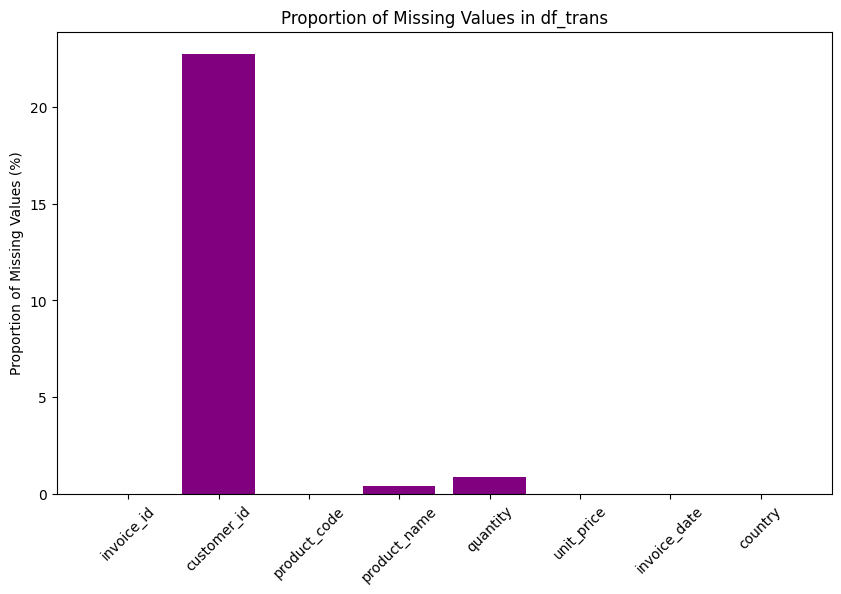

In [1]:
import pandas as pd

df_clients = pd.read_csv('../../data/customers.csv')
df_trans = pd.read_csv('../../data/transactions.csv')

print(df_clients.head())
#    customer_id / country / first_purchase / last_purchase  / total_spent /  avg_basket / recency_days / tenure_days
print(df_trans.head())
#   invoice_id  / customer_id / product_code  / unit_price / invoice_date / country

# Etape 1 

#Nb customers
nb_customers= len(df_clients['customer_id'].unique()) 
print(f'Number of customers: {nb_customers}')

nb_transactions = len(df_trans['invoice_id'])
print(f'Number of transactions: {nb_transactions}')

min_date_transaction = df_trans['invoice_date'].min()
print(f'Minimum date of transaction: {min_date_transaction}')
max_date_transaction = df_trans['invoice_date'].max()
print(f'Maximum date of transaction: {max_date_transaction}')

# Quelles colonnes contiennent des valeurs manquantes, et dans quelle proportion ?
missing_values_clients = df_clients.isnull().sum()
missing_values_trans = df_trans.isnull().sum()
print(f"Valeurs manquantes df_clients {missing_values_clients}")
print(f"Valeurs manquantes df_trans {missing_values_trans}")

#proportion 
print("\nProportion valeur manquante :\n")
proportion_missing_trans = missing_values_trans / len(df_trans) * 100
print(proportion_missing_trans)


#Data quality report 
report_clients = pd.DataFrame({
    'Column': df_clients.columns,
    'Missing Values': df_clients.isnull().sum().values,
    'Proportion Missing (%)': df_clients.isnull().mean().values * 100,
    'Data Type': df_clients.dtypes.values
})

print("\nData Quality Report for df_clients:\n")
print(report_clients)

report_trans = pd.DataFrame({
    'Column': df_trans.columns,
    'Missing Values': df_trans.isnull().sum().values,
    'Proportion Missing (%)': df_trans.isnull().mean().values * 100,
    'Data Type': df_trans.dtypes.values
})

print("\nData Quality Report for df_trans:\n")
print(report_trans)

# Graph
import matplotlib.pyplot as plt
plt.ion()

plt.figure(figsize=(10, 6))
plt.bar(report_trans['Column'], report_trans['Proportion Missing (%)'], color='purple')
plt.ylabel('Proportion of Missing Values (%)')
plt.title('Proportion of Missing Values in df_trans')
plt.xticks(rotation=45)
# plt.show(block=False)

plt.savefig('data_quality_report.png')